In [2]:
import warnings
warnings.filterwarnings('ignore')

# for interactive 
#from itables import init_notebook_mode
#init_notebook_mode(all_interactive = True)
#import itables.options as opt
#opt.maxBytes = 2**20
#opt.maxColumns= 0

import pyfolio as pf
import yfinance as yf 

In [ ]:
# pip show numpy
# !pip install pandas==1.3.5 

In [3]:
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [4]:
from myPortfolioManagement.myData import * 
from myPortfolioManagement.myPortfolioOptimisation import *
from myPortfolioManagement.myReturns import *
from myPortfolioManagement.myPerformanceAnalytics import *
from myPortfolioManagement.myBacktesting import *

### Portfolio Tickers and Candidate Portfolios 

- Global Equities 
- Absolute Return 
- Commodities 
- Precious Metals and Gold 
- Bonds 
- Direct Property 
- 60/40 Portfolio 
- UK Credit 
- Cash 

In [5]:
df_prices = get_fidelity_prices()

In [6]:
drop_funds = ['HgCapital Trust Ord', 
              'L&G Cash Trust I Acc',
              'Vanguard UK Infl-Lnkd Gilt Idx £ Inc', 
              'WisdomTree Physical Precious Metals ETC GBP', 
              'M&G Emerging Markets Bond GBP I Inc', 
              'Royal London Sterl Extra Yld Bd A',
              'Royal London Sustainable Div C Acc', 
              'Vanguard Glb Bd Idx £ H Dist',
              'VT Argonaut Absolute Return R GBP Acc',
              'Invesco EQQQ NASDAQ-100 ETF GBP',
               'Allianz Strategic Bond C Inc',
              #  'SLI UK Real Estate Platform 1 Inc', 
              # 'Vanguard UK Infl-Lnkd Gilt Idx £ Inc',
              #'Invesco EQQQ NASDAQ-100 ETF GBP'] 
               'HarbourVest Global Priv Equity Ord']
              #'Scottish Mortgage Ord']
              # 'Vanguard UK Infl-Lnkd Gilt Idx £ Inc', 
              # 'Vanguard Glb Bd Idx £ H Dist',
              # 'M&G Emerging Markets Bond GBP I Inc'
df_prices = df_prices[-df_prices['fund'].isin(drop_funds)]

In [7]:
df_plot = df_prices.pivot_table(index='Date', 
                                columns='fund', 
                                values='price')

In [8]:
ret = calculate_returns(df_plot)
performance_overview(ret)

,start,end,rf,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
BlackRock Natural Res Gr & Inc D Inc,2011-05-07,2023-01-13,0.0,0.472586,0.033667,-0.475024,0.284176,0.814433,0.070875
BlackRock Ntrl Resources Gr & Inc D Acc,2011-05-07,2023-01-13,0.0,0.66368,0.044514,-0.429337,0.331517,1.043248,0.103682
Fidelity Global Technology W-Acc-GBP,2000-10-03,2023-01-13,0.0,3.506706,0.069917,-0.741935,0.466548,0.984369,0.094236
Fundsmith Equity I Acc,2010-11-02,2023-01-13,0.0,5.017614,0.158517,-0.220427,1.227408,3.92131,0.719134
Pyrford Glbl Tot Ret(Sterling)B GBP Acc,2015-12-12,2023-01-13,0.0,0.271,0.03441,-0.093829,0.849046,5.03795,0.366727
SLI UK Real Estt Accumulation Fdr P1Inc,2016-03-19,2023-01-13,0.0,-0.0444,-0.006637,-0.166824,0.019176,0.032164,-0.039785
Scottish Mortgage Ord,2000-01-02,2023-01-13,0.0,7.072765,0.094922,-0.636268,0.450683,1.040017,0.149185
Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc,2009-06-24,2023-01-13,0.0,4.194633,0.129246,-0.255935,0.969436,4.297123,0.504995
WisdomTree Physical Gold GBP,2007-10-30,2023-01-13,0.0,2.865336,0.092988,-0.420556,0.543014,1.27904,0.221108
abrdn Short Dur Gbl Infl Lnk P1 Inc,2014-09-17,2023-01-13,0.0,0.015597,0.001861,-0.118653,0.078059,0.110707,0.015686


In [9]:
ret

fund,BlackRock Natural Res Gr & Inc D Inc,BlackRock Ntrl Resources Gr & Inc D Acc,Fidelity Global Technology W-Acc-GBP,Fundsmith Equity I Acc,Pyrford Glbl Tot Ret(Sterling)B GBP Acc,SLI UK Real Estt Accumulation Fdr P1Inc,Scottish Mortgage Ord,Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc,WisdomTree Physical Gold GBP,abrdn Short Dur Gbl Infl Lnk P1 Inc
Date,,,,,,,,,,
2000-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,-0.020790,NaN,NaN,NaN
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,-0.018047,NaN,NaN,NaN
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,-0.004324,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2023-01-09,0.009436,0.0,0.023771,-0.002365,0.002381,0.0,0.038122,-0.006397,-0.004749,0.003380
2023-01-10,0.001060,0.0,-0.005277,-0.007817,-0.000792,0.0,-0.009580,0.006973,0.002905,-0.000595
2023-01-11,0.007845,0.0,0.016092,0.017316,0.000792,0.0,0.022569,0.013030,0.000103,0.000793


### Diversification 

In [10]:
beta_Co_Moments_table(ret, ret['Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc']).sort_values('BetaCoVariance')

,BetaCoVariance,BetaCoSkewness,BetaCoKurtosis
asset,,,
SLI UK Real Estt Accumulation Fdr P1Inc,-0.010550,0.072791,-0.006456
abrdn Short Dur Gbl Infl Lnk P1 Inc,-0.000968,0.148407,-0.008134
WisdomTree Physical Gold GBP,0.134627,-0.413657,0.148783
Pyrford Glbl Tot Ret(Sterling)B GBP Acc,0.137658,0.522256,0.282835
Fundsmith Equity I Acc,0.238226,0.979570,0.309545
BlackRock Ntrl Resources Gr & Inc D Acc,0.491746,1.807566,0.777496
BlackRock Natural Res Gr & Inc D Inc,0.498679,1.835541,0.782607
Fidelity Global Technology W-Acc-GBP,0.837689,0.675978,0.615045
Scottish Mortgage Ord,0.981829,0.738583,0.821740


In [11]:
alpha_beta_table(ret, ret['Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc'], period = 'daily')

,alpha,alpha_bull,alpha_bear,beta,beta_bull,beta_bear
asset,,,,,,
BlackRock Natural Res Gr & Inc D Inc,-0.94,-0.95,-0.80,0.43,0.35,0.62
BlackRock Ntrl Resources Gr & Inc D Acc,-0.95,-0.96,-0.81,0.42,0.34,0.60
Fidelity Global Technology W-Acc-GBP,-0.55,-0.65,-0.80,0.84,0.70,0.73
Fundsmith Equity I Acc,-0.98,-0.98,-0.97,0.21,0.12,0.28
Pyrford Glbl Tot Ret(Sterling)B GBP Acc,-0.99,-0.99,-0.99,0.07,0.10,0.12
SLI UK Real Estt Accumulation Fdr P1Inc,-0.99,-0.99,-0.99,-0.01,-0.02,0.00
Scottish Mortgage Ord,-0.06,-0.17,-0.56,0.98,0.88,0.90
WisdomTree Physical Gold GBP,-0.99,-0.98,-0.99,0.13,0.26,0.05
abrdn Short Dur Gbl Infl Lnk P1 Inc,-0.99,-0.99,-0.99,-0.00,-0.01,0.00


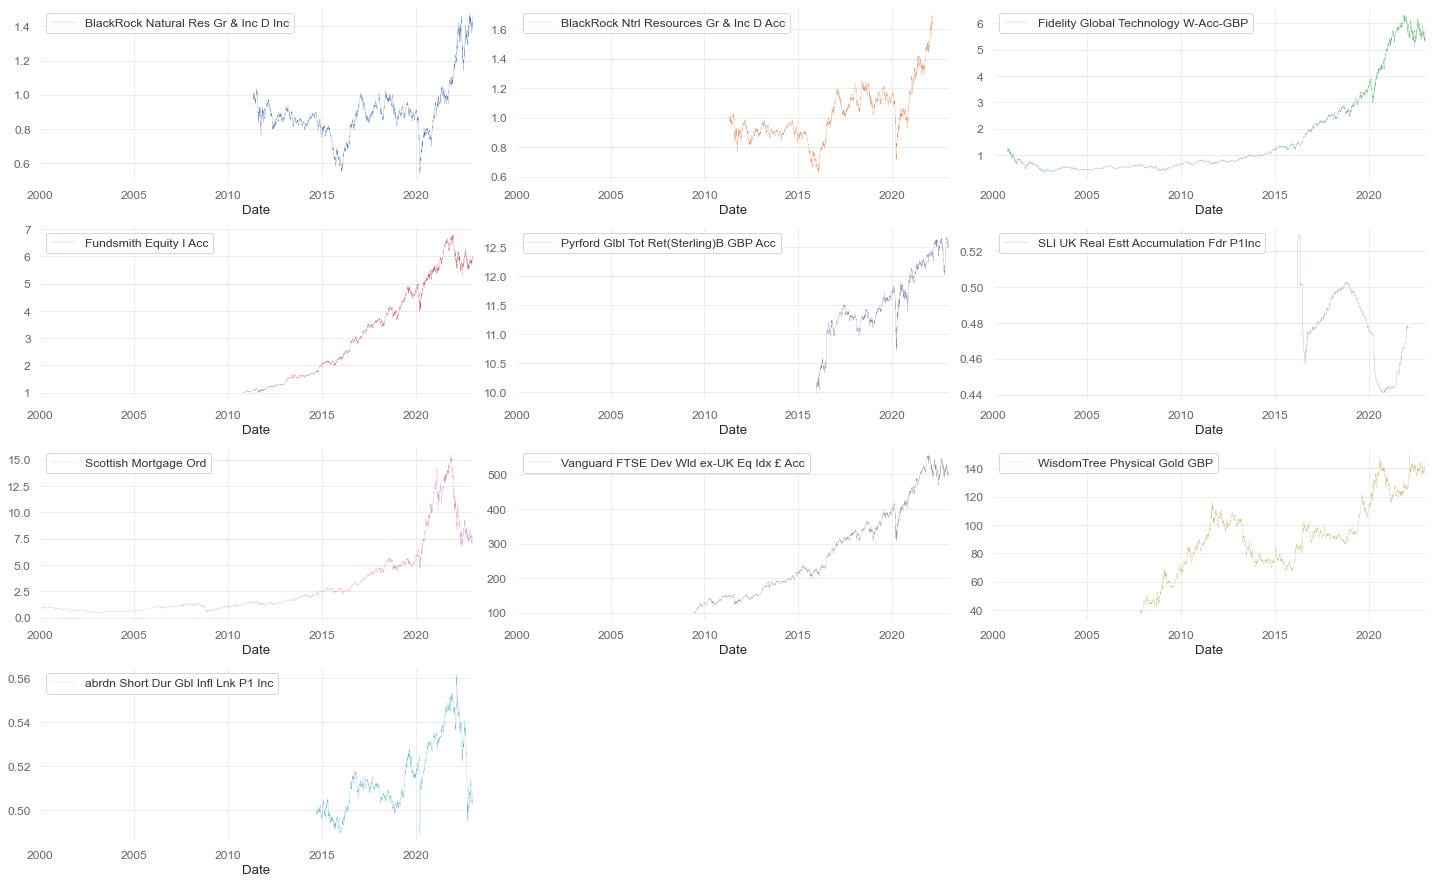

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (20, 15)
#plt.style.use('fast')

df_plot.plot(subplots=True,
          layout=(5, 3),
          sharex=False,
          sharey=False,
         #colormap='viridis',
         fontsize=12,
         legend=True,
         linewidth=0.2);
plt.tight_layout();

In [13]:
ret = calculate_returns(df_plot)
ret = ret[ret.index>='2006-01-04']
### Adjust returns for Yields 
#ret['Royal London Sterl Extra Yld Bd A'] = ret['Royal London Sterl Extra Yld Bd A'] + ffn.core.deannualize(0.05, 1)
#ret['M&G Emerging Markets Bond GBP I Inc'] = ret['M&G Emerging Markets Bond GBP I Inc'] + + ffn.core.deannualize(0.05, 1)
eq_weights = equal_weight_portfolio(ret)
#eq_weights.port_naive = [0.10, 0.10, 0.05, 0.05, 0.05, 0.10, 0.20,0.15,0.10, 0.10]

In [14]:
eq_weights

,port_naive
assets,
BlackRock Natural Res Gr & Inc D Inc,0.1
BlackRock Ntrl Resources Gr & Inc D Acc,0.1
Fidelity Global Technology W-Acc-GBP,0.1
Fundsmith Equity I Acc,0.1
Pyrford Glbl Tot Ret(Sterling)B GBP Acc,0.1
SLI UK Real Estt Accumulation Fdr P1Inc,0.1
Scottish Mortgage Ord,0.1
Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc,0.1
WisdomTree Physical Gold GBP,0.1


<AxesSubplot:title={'center':'Risk (Standard Deviation) Contribution per Asset'}>

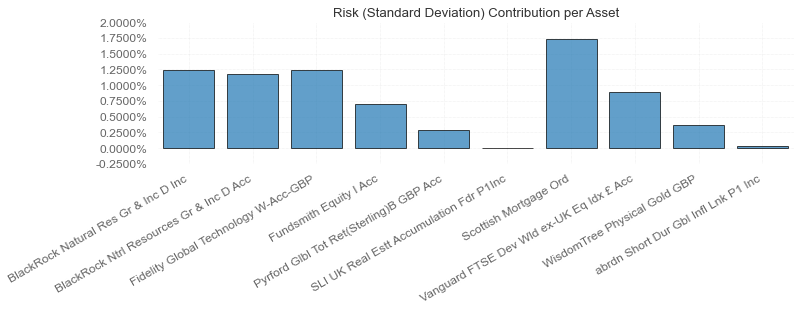

In [15]:
pl_risk = risk_contributions(port_weights = eq_weights, 
                             returns = ret,
                             risk_measure = 'MV',
                             plot = True)
pl_risk

In [16]:
eq_weights = eq_weights.iloc[:,0].to_dict()
portfolio = qs.utils.make_index(ticker_weights = eq_weights, 
                                                period='max', 
                                                rebalance = None,
                                                returns=ret, 
                                                match_dates=False)
portfolio

Date
2016-03-19    0.000000
2016-03-20    0.000000
2016-03-21    0.007710
2016-03-22    0.005862
2016-03-23    0.001518
                ...   
2023-01-09    0.006358
2023-01-10   -0.001312
2023-01-11    0.007854
2023-01-12    0.003703
2023-01-13    0.003707
Length: 2492, dtype: float64

In [17]:
ret_all_weather = get_benchmark_porfolios()['All_Weather_Dalio'].dropna()

In [18]:
ret_assets = get_stock_returns(['BRWM.L', '^GSPC' , 'IAU', 'TIP' ])

In [19]:
performance_overview(ret_assets)

,start,end,rf,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
BRWM.L,1993-12-16 00:00:00+00:00,2023-01-13 00:00:00+00:00,0.0,15.36424,0.100903,-0.991359,0.401838,1.160411,0.101783
^GSPC,1928-01-03 05:00:00+00:00,2023-01-13 05:00:00+00:00,0.0,224.173989,0.058659,-0.861896,0.38872,0.774493,0.068058
IAU,2005-01-31 05:00:00+00:00,2023-01-13 05:00:00+00:00,0.0,3.311568,0.084818,-0.547297,0.548215,1.206482,0.154977
TIP,2003-12-08 05:00:00+00:00,2023-01-13 05:00:00+00:00,0.0,0.945116,0.035449,-0.143885,0.554939,1.105361,0.246369


In [20]:
ret = convert_returns_freq(pd.DataFrame(ret_assets), convert_to = 'monthly')

In [21]:
eq_weights = equal_weight_portfolio(ret_assets)
port_ret = calculate_portfolio_returns(ret_assets, eq_weights.index.to_list(), eq_weights.port_naive.to_list())
port_ret.head()

,myPortfolio
Date,
1927-12-30 05:00:00+00:00,0.000000
1928-01-03 05:00:00+00:00,0.001416
1928-01-04 05:00:00+00:00,-0.000563
1928-01-05 05:00:00+00:00,-0.002398
1928-01-06 05:00:00+00:00,0.001567


In [22]:
ret

,BRWM.L,^GSPC,IAU,TIP
Date,,,,
1927-12-31,0.000000,0.000000,0.000000,0.000000
1928-01-31,0.000000,-0.005096,0.000000,0.000000
1928-02-29,0.000000,-0.017644,0.000000,0.000000
1928-03-31,0.000000,0.117034,0.000000,0.000000
1928-04-30,0.000000,0.024378,0.000000,0.000000
...,...,...,...,...
2022-09-30,-0.030664,-0.093396,-0.028651,-0.067323
2022-10-31,0.070299,0.079863,-0.017444,0.014204
2022-11-30,0.147279,0.053753,0.084571,0.018329


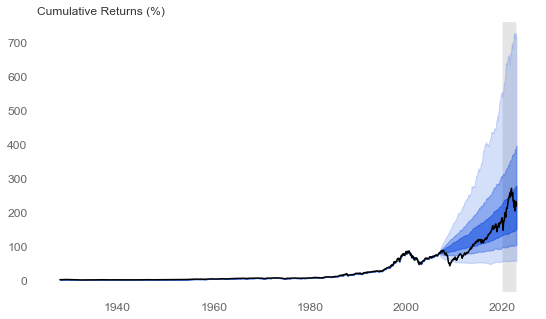

In [24]:
ret_possible_path_cum = sim_paths(ret['^GSPC'], out_of_sample_date = '2007-01-01')
dist = prep_dist(ret_possible_path_cum)
plot_fan_chart(ret['^GSPC'], dist, out_of_sample_date = '2020-01-01', chart_title = 'Cumulative Returns (%)')

In [32]:
portfolio.name = 'myPortfolio'
alpha_beta_table(portfolio, ret['^GSPC'], rf= 0.02)

,alpha,alpha_bull,alpha_bear,beta,beta_bull,beta_bear
asset,,,,,,
myPortfolio,-0.99,-0.99,-1.0,-0.01,-0.01,-0.04


In [36]:
beta_Co_Moments_table(pd.DataFrame(portfolio), ret['^GSPC']).sort_values('BetaCoVariance')

,BetaCoVariance,BetaCoSkewness,BetaCoKurtosis
asset,,,
myPortfolio,-0.003972,-0.022451,-0.002442


In [49]:
mystock = pd.DataFrame(portfolio)

In [53]:
#port_ret = ffn.core.deannualize(portfolio, 12)
port_ret = portfolio
port_ret.index = port_ret.index.tz_localize('utc')
port_ret

Date
2016-03-19 00:00:00+00:00    0.000000
2016-03-20 00:00:00+00:00    0.000000
2016-03-21 00:00:00+00:00    0.007710
2016-03-22 00:00:00+00:00    0.005862
2016-03-23 00:00:00+00:00    0.001518
                               ...   
2023-01-09 00:00:00+00:00    0.006358
2023-01-10 00:00:00+00:00   -0.001312
2023-01-11 00:00:00+00:00    0.007854
2023-01-12 00:00:00+00:00    0.003703
2023-01-13 00:00:00+00:00    0.003707
Name: myPortfolio, Length: 2492, dtype: float64

In [55]:
returns_benchmark = ret['^GSPC']
#returns_benchmark = ffn.core.deannualize(returns_benchmark, 12)
returns_benchmark

Date
1927-12-31    0.000000
1928-01-31   -0.005096
1928-02-29   -0.017644
1928-03-31    0.117034
1928-04-30    0.024378
                ...   
2022-09-30   -0.093396
2022-10-31    0.079863
2022-11-30    0.053753
2022-12-31   -0.058971
2023-01-13    0.041565
Name: ^GSPC, Length: 1142, dtype: float64

In [56]:
returns_benchmark.index = returns_benchmark.index.tz_localize('utc')
returns_benchmark

Date
1927-12-31 00:00:00+00:00    0.000000
1928-01-31 00:00:00+00:00   -0.005096
1928-02-29 00:00:00+00:00   -0.017644
1928-03-31 00:00:00+00:00    0.117034
1928-04-30 00:00:00+00:00    0.024378
                               ...   
2022-09-30 00:00:00+00:00   -0.093396
2022-10-31 00:00:00+00:00    0.079863
2022-11-30 00:00:00+00:00    0.053753
2022-12-31 00:00:00+00:00   -0.058971
2023-01-13 00:00:00+00:00    0.041565
Name: ^GSPC, Length: 1142, dtype: float64

In [64]:
## Optimise portfolios 
portfolios = make_standard_portfolios(ret.fillna(0),
                             weight_min=0.02, weight_max = 0.4, 
                             rebalance = None)

In [65]:
portfolios

[            port_GMV  port_HRP  port_max_Sharpe  port_min_CVaR  \
 Date                                                             
 1927-12-31  0.000000  0.000000         0.000000       0.000000   
 1928-01-31 -0.000623 -0.000453        -0.001944      -0.000672   
 1928-02-29 -0.002157 -0.001567        -0.006732      -0.002325   
 1928-03-31  0.014310  0.010392         0.044652       0.015424   
 1928-04-30  0.002981  0.002165         0.009301       0.003213   
 ...              ...       ...              ...            ...   
 2022-09-30 -0.052193 -0.050093        -0.065634      -0.052790   
 2022-10-31  0.013933  0.013613         0.033328       0.014024   
 2022-11-30  0.059180  0.062311         0.054541       0.058290   
 2022-12-31 -0.000245  0.001922        -0.018713      -0.000862   
 2023-01-13  0.040007  0.041593         0.038752       0.039556   
 
             port_inverse_vol  port_naive   port_rp  
 Date                                                
 1927-12-31        

In [66]:
portf_series = portfolios[0]
port_weights = portfolios[1]

In [74]:
port_weights

,port_weight,port_naive,por_rp_MV,port_inverse_vol,port_min_vol,port_target_CVAR,port_max_Sharpe
BRWM.L,0.111204,0.25,0.11,0.0964,0.07773,0.06821,0.04177
^GSPC,0.088796,0.25,0.11,0.0862,0.12227,0.13179,0.38153
IAU,0.400000,0.25,0.23,0.2152,0.40000,0.40000,0.26132
TIP,0.400000,0.25,0.55,0.6022,0.40000,0.40000,0.31539


In [78]:
portf_series

,port_GMV,port_HRP,port_max_Sharpe,port_min_CVaR,port_inverse_vol,port_naive,port_rp
Date,,,,,,,
1927-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1928-01-31,-0.000623,-0.000453,-0.001944,-0.000672,-0.000439,-0.001274,-0.000561
1928-02-29,-0.002157,-0.001567,-0.006732,-0.002325,-0.001521,-0.004411,-0.001941
1928-03-31,0.014310,0.010392,0.044652,0.015424,0.010088,0.029258,0.012874
1928-04-30,0.002981,0.002165,0.009301,0.003213,0.002101,0.006094,0.002682
...,...,...,...,...,...,...,...
2022-09-30,-0.052193,-0.050093,-0.065634,-0.052790,-0.057715,-0.055009,-0.057264
2022-10-31,0.013933,0.013613,0.033328,0.014024,0.018461,0.036731,0.020318
2022-11-30,0.059180,0.062311,0.054541,0.058290,0.048068,0.075983,0.051646


# FIX ISSUE WITH Portfolios 
# weight and series columns do not align 